# 1. Numerical Representation & Fourier Transform 

To compute additional quantities associated to complexity and entropy of each story, we now encode their information in numerical arrays. The key insight is to note that each character may be mapped to a unique numerical value once a certain convention is assumed. Therefore, each text will be mapped to a one dimensional system, analogous to DNA or to music. 

For now, we adopt the Unicode convention for each, character, implemented by the function $\tt ord()$ from "ordinal number".

In [ ]:
# ord function examples
print(ord('a'))   # prints the Unicode code point of the character 'a'
print(ord('b'))   # prints the Unicode code point of the character 'b'
print(ord('A'))   # prints the Unicode code point of the character 'A'
print(ord(' '))   # prints the Unicode code point of the space character
print(ord('\n'))  # prints the Unicode code point of the newline character \n 

97
98
65
32
10


We now apply the above consideration systematically for each text. We shall then save the numerical representations in the folder $\tt numerical\_ representations$ inside the $\tt gold$ folder. To do so, we use the $\tt string\_to\_numerical function$ defined in $\tt text\_tools$ to convert arbitrary strings to $\tt Numpy$ arrays.

In [ ]:
text_tools.string_to_numerical('Hello')  # converts the string 'Hello' to a list of numerical values based on Unicode code points

array([ 72, 101, 108, 108, 111])

In [ ]:
# dictionary: name -> numerical representation
numerical_dict = { text: text_tools.string_to_numerical( biblio.texts[text] ) for text in biblio.texts.keys() }
np.save('data/gold/numerical_dict.npy', numerical_dict)  # saves the numerical dictionary to a file in NumPy format

# prints the dictionary
print( numerical_dict ) 

{'dreams_in_the_witch': array([ 68,  82,  69, ..., 110,  46,  10], shape=(86779,)), 'ex_oblivione': array([ 69,  88,  32, ..., 114,  46,  10], shape=(3814,)), 'poetry_of_gods': array([80, 79, 69, ..., 46, 34, 10], shape=(10560,)), 'doorstep': array([ 84,  72,  69, ..., 115,  46,  10], shape=(60265,)), 'colour_out_of_space': array([ 84,  72,  69, ..., 112,  46,  10], shape=(68090,)), 'iranon': array([ 84,  72,  69, ..., 100,  46,  10], shape=(14159,)), 'street': array([ 84,  72,  69, ..., 116,  46,  10], shape=(12256,)), 'arthur_jermyn': array([ 70,  65,  67, ..., 100,  46,  10], shape=(21417,)), 'crawling_chaos': array([ 84,  72,  69, ..., 114,  46,  10], shape=(17001,)), 'ulthar': array([ 84,  72,  69, ..., 116,  46,  10], shape=(7351,)), 'azathoth': array([65, 90, 65, ..., 46, 46, 10], shape=(2537,)), 'shadow_out_of_time': array([ 84,  72,  69, ..., 103,  46,  10], shape=(147558,)), 'haunter': array([84, 72, 69, ..., 46, 46, 10], shape=(54262,)), 'martins_beach': array([ 84,  72,  69

We now proceed to perform Fourier transforms for each element of the above dictionary by using the $\tt Numpy$ function $\tt np.fft.fft()$, where fft means "Fast Fourier Transform", also stored in a dictionary.

In [ ]:
# dictionary: name -> numerical representation
fourier_dict = { text: np.fft.fft(numerical_dict[text]) for text in biblio.texts.keys()}
np.save('data/gold/fourier_dict.npy', fourier_dict)     # saves the Fourier dictionary to a file in NumPy format

# prints the dictionary
print( fourier_dict ) 

{'dreams_in_the_witch': array([8.05992600e+06    +0.j        , 1.47838381e+04-11613.99951172j,
       2.52730297e+02 -6743.00778385j, ...,
       1.59900723e+03 -6543.80178881j, 2.52730297e+02 +6743.00778385j,
       1.47838381e+04+11613.99951172j], shape=(86779,)), 'ex_oblivione': array([ 3.49646000e+05+4.54747351e-13j, -3.19942898e+02-9.49138172e+02j,
       -1.39517203e+03-2.30427990e+02j, ...,
        5.14614882e+02-4.54313296e+02j, -1.39517203e+03+2.30427990e+02j,
       -3.19942898e+02+9.49138172e+02j], shape=(3814,)), 'poetry_of_gods': array([ 9.71449000e+05   +0.j        , -8.81389820e+02-1689.14068065j,
        4.21264437e+02-2797.36309188j, ...,
        1.92825075e+03+4813.6250037j ,  4.21264437e+02+2797.36309188j,
       -8.81389820e+02+1689.14068065j], shape=(10560,)), 'doorstep': array([ 5.51403800e+06-2.21234586e-10j,  1.14065397e+03-2.89198026e+04j,
       -6.68761678e+03-4.15037747e+03j, ...,
       -8.36578424e+03+5.44296691e+03j, -6.68761678e+03+4.15037747e+03j,
     

# 3. Example Plots

To make our approach less abstract, we shall plot the results for Lovecraft's most famous story "The Call of Cthulhu", represented by the key $\tt cthulhu$.

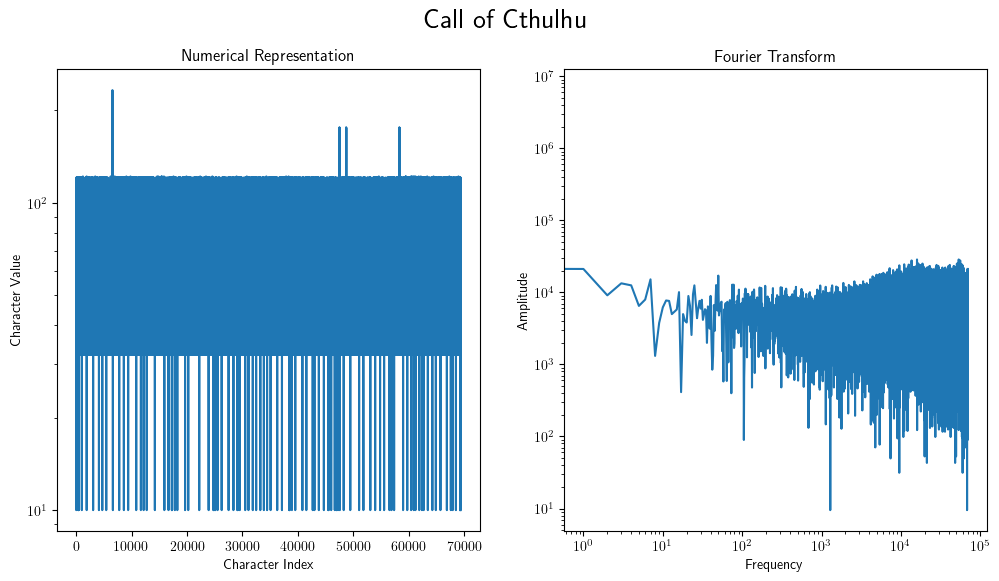

In [ ]:
# plot Call of Cthulhu

# subplot with 1 row and 2 columns
fig, ax = plt.subplots(1, 2, figsize=(12, 6))  # creates a figure and an array of axes for plotting

# left plot: numerical representation of Call of Cthulhu
ax[0].plot( numerical_dict['cthulhu'] )  # plots the text of Call of Cthulhu
ax[0].set_title('Numerical Representation')  # sets the title of the plot
ax[0].set_xlabel('Character Index')  # sets the label for the x-axis
ax[0].set_ylabel('Character Value')  # sets the label for the y-axis  

# log scale - left plot
#ax[0].set_xscale('log')  # sets the x-axis to a logarithmic scale
ax[0].set_yscale('log')  # sets the y-axis to a logarithmic scale

###### 

# right plot: numerical representation of Call of Cthulhu
ax[1].plot( np.abs(fourier_dict['cthulhu']) )  # plots the text of Call of Cthulhu
ax[1].set_title('Fourier Transform')  # sets the title of the plot
ax[1].set_xlabel('Frequency')  # sets the label for the x-axis  
ax[1].set_ylabel('Amplitude')  # sets the label for the y-axis

# log scale - right plot
ax[1].set_xscale('log')  # sets the y-axis to a logarithmic scale
ax[1].set_yscale('log')  # sets the y-axis to a logarithmic scale



# global title for the figure
fig.suptitle('Call of Cthulhu', fontsize=20)  # sets the overall title for the figure

# displays the plots
plt.show()